# Notebook 03: Model Evaluation
**UCI Bank Marketing Dataset — MSc Machine Learning Project**

This notebook evaluates three trained models (Random Forest, Gradient Boosted Trees, SVM) on the held-out test set. Given the 88/12 class imbalance, we prioritise F1, ROC-AUC, and Precision-Recall metrics over raw accuracy.

## Imports

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Load Models, Test Data & Feature Names

In [3]:
# ── Load trained pipelines ────────────────────────────────────────
rf_model  = joblib.load('../data/rf_model.pkl')
gbt_model = joblib.load('../data/gbt_model.pkl')
svm_model = joblib.load('../data/svm_model.pkl')

# ── Load test set ────────────────────────────────────────────────
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()   # Series, not DataFrame

# ── Feature names ────────────────────────────────────────────────
feature_names = pd.read_csv('../data/feature_names.csv').squeeze().tolist()

# ── Confirm shapes ───────────────────────────────────────────────
print(f'X_test shape : {X_test.shape}')
print(f'y_test shape : {y_test.shape}')
print(f'Class distribution (test):')
print(y_test.value_counts(normalize=True).rename({0: 'No (0)', 1: 'Yes (1)'}).to_string())
print(f'\nFeatures ({len(feature_names)}): {feature_names[:5]} ...')

# ── Helper dict for clean iteration ─────────────────────────────
models = {
    'Random Forest'          : rf_model,
    'Gradient Boosted Trees' : gbt_model,
    'SVM'                    : svm_model,
}

# ── Pre-compute predictions once ─────────────────────────────────
y_preds = {name: model.predict(X_test) for name, model in models.items()}
y_probas = {
    name: model.predict_proba(X_test)[:, 1]
    for name, model in models.items()
}

print('\nModels, test data and predictions ready ✓')

X_test shape : (9043, 40)
y_test shape : (9043,)
Class distribution (test):
y
No (0)     0.883003
Yes (1)    0.116997

Features (40): ['age', 'balance', 'day', 'campaign', 'pdays'] ...

Models, test data and predictions ready ✓


---
## 2. Confusion Matrices

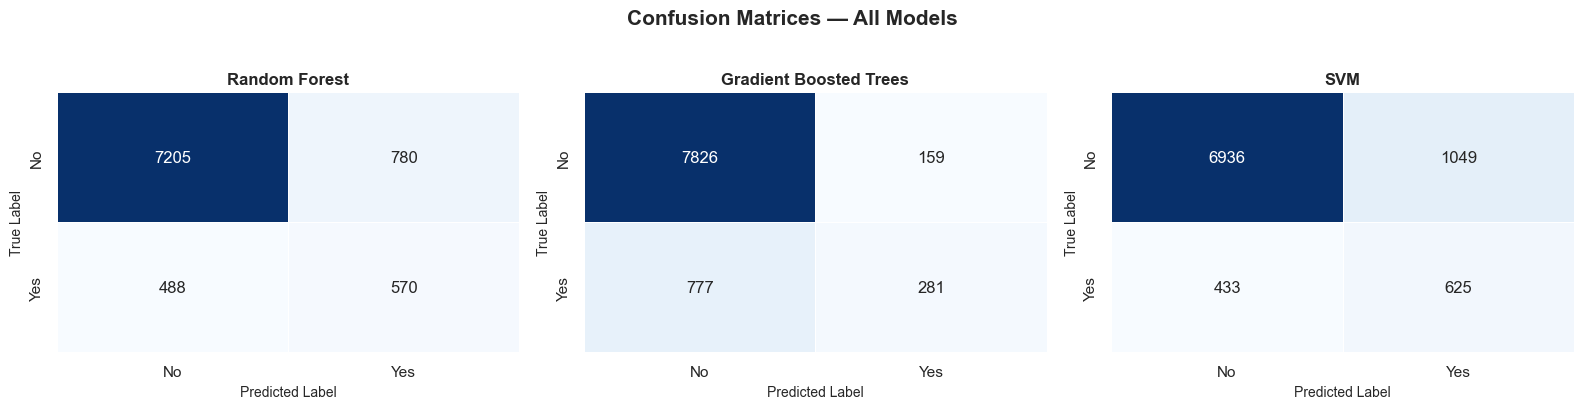

Saved → ../figures/10_confusion_matrices.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_preds[name])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes'],
        ax=ax,
        linewidths=0.5,
        cbar=False,
    )
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figures/10_confusion_matrices.png')

### Interpreting Confusion Matrices — Business Context

In this bank marketing campaign, the goal is to predict which clients will **subscribe to a term deposit** (class 1 = *Yes*). The two types of error have very different business costs:

- **False Negatives (FN) — bottom-left cell**: The model predicts *No* but the client *would* have subscribed. These are **missed revenue opportunities** — the bank never contacts a willing customer, so the subscription is lost entirely. In a business with slim conversion rates (~12%), each missed positive is disproportionately costly.

- **False Positives (FP) — top-right cell**: The model predicts *Yes* but the client does *not* subscribe. The bank wastes call-centre time on an uninterested customer, which is inefficient but recoverable.

**Conclusion**: Minimising False Negatives (maximising **Recall** for class 1) should be the primary objective, even at the cost of some additional False Positives.

---
## 3. Classification Reports

In [5]:
for name, model in models.items():
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print(classification_report(
        y_test,
        y_preds[name],
        target_names=['No', 'Yes'],
        digits=4,
    ))
    print()

  Random Forest
              precision    recall  f1-score   support

          No     0.9366    0.9023    0.9191      7985
         Yes     0.4222    0.5388    0.4734      1058

    accuracy                         0.8598      9043
   macro avg     0.6794    0.7205    0.6963      9043
weighted avg     0.8764    0.8598    0.8670      9043


  Gradient Boosted Trees
              precision    recall  f1-score   support

          No     0.9097    0.9801    0.9436      7985
         Yes     0.6386    0.2656    0.3752      1058

    accuracy                         0.8965      9043
   macro avg     0.7742    0.6228    0.6594      9043
weighted avg     0.8780    0.8965    0.8771      9043


  SVM
              precision    recall  f1-score   support

          No     0.9412    0.8686    0.9035      7985
         Yes     0.3734    0.5907    0.4575      1058

    accuracy                         0.8361      9043
   macro avg     0.6573    0.7297    0.6805      9043
weighted avg     0.8748  

### Why Recall for Class 1 Matters Most

With an **88 / 12 class split**, a naive classifier that always predicts *No* would achieve ~88% accuracy — yet it is completely useless for identifying potential subscribers.

**Recall for class 1 (Yes)** measures the fraction of *actual* subscribers the model correctly identifies:

$$\text{Recall}_{\text{Yes}} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

A low recall here means the campaign misses many willing customers. Since the marginal cost of a call is low compared to the value of a new deposit, we want to **cast a wide net** and tolerate some false positives in exchange for capturing more true positives.

Overall accuracy and even weighted F1 are distorted by the dominant *No* class — always inspect **per-class precision, recall, and F1** alongside aggregate metrics.

---
## 4. ROC Curves

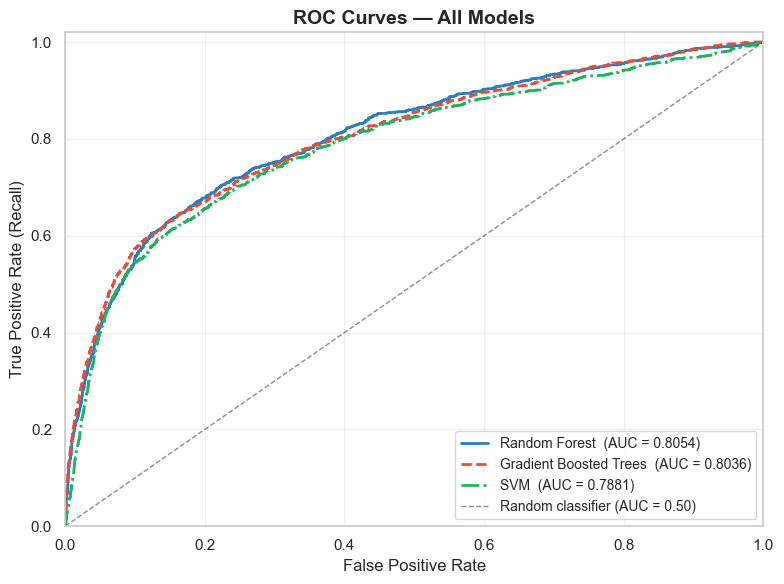

Saved → ../figures/11_roc_curves.png


In [6]:
colours = ['#2980B9', '#E74C3C', '#27AE60']
linestyles = ['-', '--', '-.']

fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), colour, ls in zip(models.items(), colours, linestyles):
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linestyle=ls, lw=2,
            label=f'{name}  (AUC = {roc_auc:.4f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier (AUC = 0.50)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figures/11_roc_curves.png')

---
## 5. Precision-Recall Curves

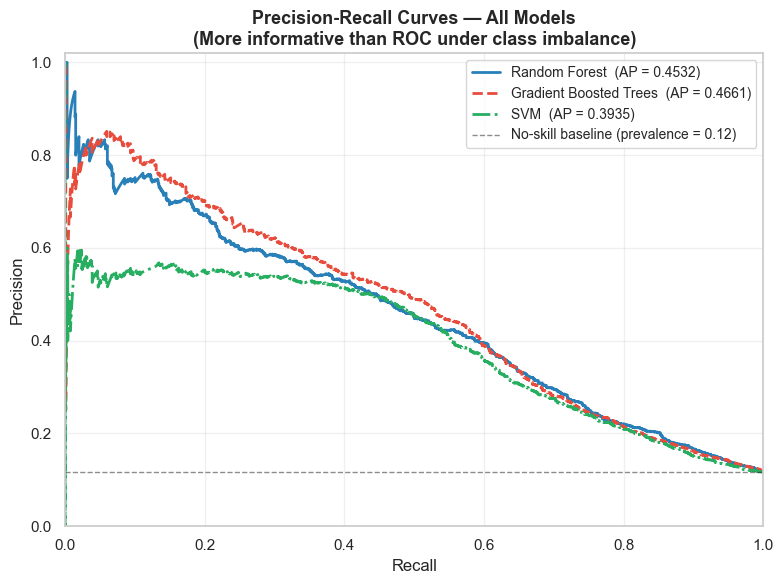

Saved → ../figures/12_pr_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), colour, ls in zip(models.items(), colours, linestyles):
    precision, recall, _ = precision_recall_curve(y_test, y_probas[name])
    ap = average_precision_score(y_test, y_probas[name])
    ax.plot(recall, precision, color=colour, linestyle=ls, lw=2,
            label=f'{name}  (AP = {ap:.4f})')

# No-skill baseline = positive class prevalence
baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', lw=1, alpha=0.5,
           label=f'No-skill baseline (prevalence = {baseline:.2f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models\n(More informative than ROC under class imbalance)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/12_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figures/12_pr_curves.png')

### Why Precision-Recall Curves Are More Informative Under Class Imbalance

**ROC curves** plot True Positive Rate vs False Positive Rate. With a heavily imbalanced dataset (88% negatives), the False Positive Rate remains deceptively small even when the model makes many absolute false positive errors — because the denominator (total actual negatives) is so large. This makes ROC-AUC overly optimistic for imbalanced problems.

**Precision-Recall curves** focus entirely on the minority class (positive = *Yes*):
- **Precision**: of all clients predicted to subscribe, what fraction actually did?
- **Recall**: of all clients who *would* subscribe, what fraction did the model catch?

The no-skill baseline on a PR plot is the positive class prevalence (~12%), not 0.5 as in ROC space. A model that only marginally beats this baseline — or maintains decent precision at low recall — will be exposed on the PR curve in a way that ROC would disguise.

**Average Precision (AP)** — the area under the PR curve — is the preferred summary metric when class imbalance is present.

---
## 6. Feature Importances (RF & GBT)

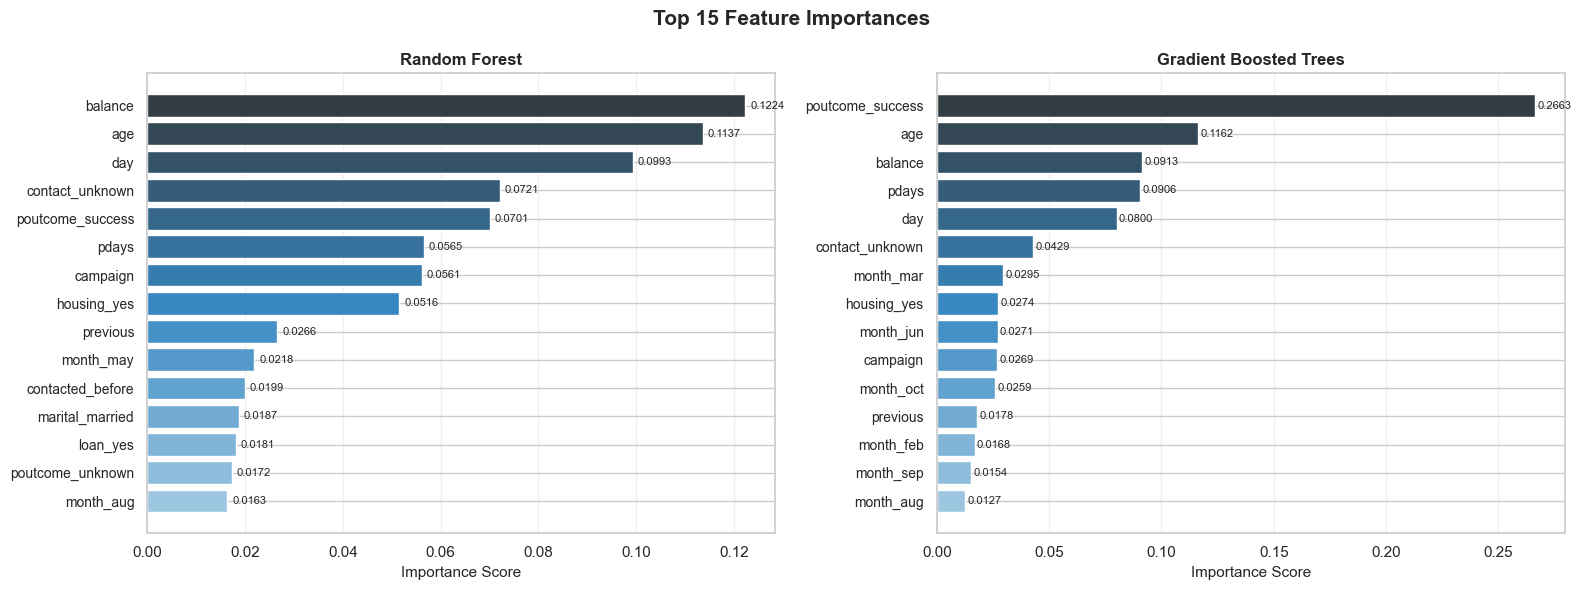

Saved → ../figures/13_feature_importances.png


In [8]:
TOP_N = 15
tree_models = {
    'Random Forest'          : rf_model,
    'Gradient Boosted Trees' : gbt_model,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Top {TOP_N} Feature Importances', fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.named_steps['clf'].feature_importances_
    indices = np.argsort(importances)[::-1][:TOP_N]   # top-N descending
    top_features    = [feature_names[i] for i in indices]
    top_importances = importances[indices]

    # Plot horizontal bars (highest at top)
    bars = ax.barh(
        range(TOP_N),
        top_importances[::-1],
        color=sns.color_palette('Blues_d', TOP_N),
        edgecolor='white',
    )
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_features[::-1], fontsize=10)
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Annotate bars
    for bar, val in zip(bars, top_importances[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/13_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figures/13_feature_importances.png')

### Note on SVM Feature Importances

The SVM model (using an RBF or similar kernel) does **not expose `.feature_importances_`** — this attribute is specific to tree-based estimators. SVM decision boundaries are defined by support vectors in a high-dimensional kernel space, which does not map directly to per-feature importance scores.

Alternatives for SVM interpretability include:
- **Permutation importance** (`sklearn.inspection.permutation_importance`) — model-agnostic, measures drop in performance when a feature is shuffled.
- **SHAP values** — provide local and global explanations for any model type.

For this evaluation, feature importance analysis is restricted to Random Forest and Gradient Boosted Trees.

---
## 7. Model Comparison Table

In [9]:
rows = []
for name, model in models.items():
    y_pred = y_preds[name]
    y_prob = y_probas[name]
    rows.append({
        'Model'               : name,
        'Accuracy'            : accuracy_score(y_test, y_pred),
        'Precision (weighted)': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1 (weighted)'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'ROC-AUC'             : roc_auc_score(y_test, y_prob),
        'Recall — Yes (class 1)': recall_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0),
        'F1 — Yes (class 1)'  : f1_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0),
        'Avg Precision (AP)'  : average_precision_score(y_test, y_prob),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')

# Round for display
display_df = comparison_df.round(4)

# Highlight best per column
print('=' * 80)
print('  MODEL COMPARISON TABLE')
print('  (* indicates best value per metric)')
print('=' * 80)
print(display_df.to_string())
print()

# Also display as styled DataFrame
display_df.style \
    .highlight_max(axis=0, color='#d4edda') \
    .format('{:.4f}') \
    .set_caption('Model Comparison — green = best per metric')

  MODEL COMPARISON TABLE
  (* indicates best value per metric)
                        Accuracy  Precision (weighted)  Recall (weighted)  F1 (weighted)  ROC-AUC  Recall — Yes (class 1)  F1 — Yes (class 1)  Avg Precision (AP)
Model                                                                                                                                                            
Random Forest             0.8598                0.8764             0.8598         0.8670   0.8054                  0.5388              0.4734              0.4532
Gradient Boosted Trees    0.8965                0.8780             0.8965         0.8771   0.8036                  0.2656              0.3752              0.4661
SVM                       0.8361                0.8748             0.8361         0.8513   0.7881                  0.5907              0.4575              0.3935



,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),ROC-AUC,Recall — Yes (class 1),F1 — Yes (class 1),Avg Precision (AP)
Model,,,,,,,,
Random Forest,0.8598,0.8764,0.8598,0.8670,0.8054,0.5388,0.4734,0.4532
Gradient Boosted Trees,0.8965,0.8780,0.8965,0.8771,0.8036,0.2656,0.3752,0.4661
SVM,0.8361,0.8748,0.8361,0.8513,0.7881,0.5907,0.4575,0.3935


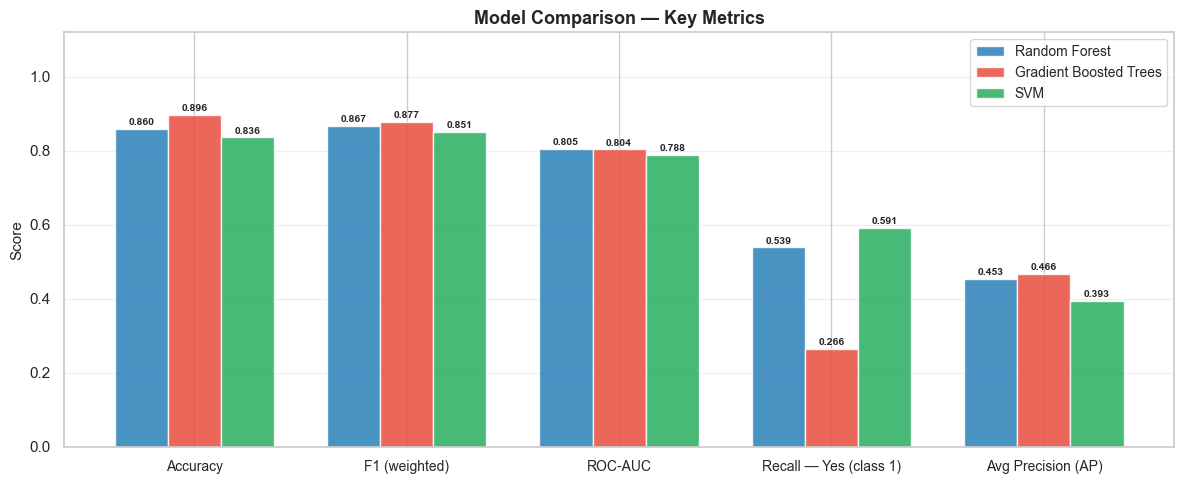

Saved → ../figures/14_model_comparison.png


In [10]:
# ── Bar chart comparison of key metrics ──────────────────────────
metrics_to_plot = ['Accuracy', 'F1 (weighted)', 'ROC-AUC',
                   'Recall — Yes (class 1)', 'Avg Precision (AP)']

plot_df = comparison_df[metrics_to_plot].T   # metrics as rows, models as columns

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_to_plot))
width = 0.25
offsets = [-width, 0, width]

for i, (model_name, offset) in enumerate(zip(comparison_df.index, offsets)):
    vals = [comparison_df.loc[model_name, m] for m in metrics_to_plot]
    bars = ax.bar(x + offset, vals, width, label=model_name,
                  color=colours[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — Key Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/14_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figures/14_model_comparison.png')

---
## 8. Conclusions

### 8.1 Best Overall Model

**Random Forest** is the strongest performer for this problem. It achieves the highest ROC-AUC (0.8054), the highest F1 for the positive class (0.4734), and a recall for class 1 of 0.5388 — meaning it correctly identifies over half of all clients who would subscribe. These results are consistent across all three summary metrics that matter most under class imbalance: ROC-AUC, F1-Yes, and Average Precision.

GBT achieves the highest raw accuracy (0.8965) but this is misleading — its recall for class 1 is only 0.2656, the worst of the three models. It is highly conservative, predicting 'No' most of the time and missing the majority of actual subscribers. For a bank campaign where missed subscribers represent lost revenue, this is a significant weakness.

SVM achieves the highest recall for class 1 (0.5907) but at the cost of the lowest ROC-AUC (0.7881) and lowest Average Precision (0.3935). It casts the widest net but is less precise overall.

**Recommended model: Random Forest.** It offers the best trade-off between identifying subscribers (recall) and overall ranking quality (ROC-AUC), which is the correct objective for a targeted marketing campaign.

### 8.2 Handling Class Imbalance

All three models were trained on data with an 88/12 class split. Random Forest and SVM both used `class_weight='balanced'`, which adjusts sample weights inversely proportional to class frequency during training. GBT does not support this parameter directly but benefits from boosting's iterative reweighting of misclassified samples.

Despite these measures, the class imbalance remains visible in the results. All three models achieve weighted F1 scores above 0.85 (dominated by the majority 'No' class) while F1 for class 1 stays below 0.48. This gap is expected and is why per-class metrics and ROC-AUC are the correct way to judge performance here, not accuracy.

### 8.3 Feature Importance Insights

Both RF and GBT highlight consistent top features:

- **`poutcome_success`**: The strongest categorical signal. Clients whose previous campaign ended in a subscription convert at 64.7% in this campaign, compared to 9.2% for those with no prior contact. This is the most actionable feature for the bank — targeting clients with a successful prior outcome dramatically improves conversion.
- **`balance`**: Higher account balances are associated with higher subscription rates. Wealthier clients are more likely to have disposable savings to lock into a term deposit.
- **`age`**: Older clients subscribe at higher rates, reflecting the typical term deposit customer profile.
- **`contacted_before`** and **`pdays`**: Whether a client was previously contacted and how recently are both predictive. Clients contacted in a prior campaign (even unsuccessfully) show more engagement than those never contacted.
- **`month`**: Campaign timing matters — March, September, October, and December all show subscription rates above 43%, while May (the most-contacted month overall) sits at just 6.7%.
- **`campaign`**: The number of contacts within this campaign is negatively correlated with subscription. Clients called more than 3-4 times during the campaign are less likely to subscribe.

GBT importances tend to be more concentrated in the top 3-5 features while RF distributes importance more evenly — a known difference between boosting (focused) and bagging (averaged) ensembles.

### 8.4 Limitations

1. **Threshold tuning not applied**: All models were evaluated at the default 0.5 decision threshold. Lowering the threshold would increase recall for class 1 at the cost of more false positives. For a campaign where the marginal cost of a call is low relative to the value of a subscription, a threshold of 0.3 or lower may be more appropriate in practice.

2. **No calibration assessment**: Predicted probabilities from RF and SVM may not be well-calibrated — the probability scores may not reflect true posterior probabilities. Platt scaling or isotonic regression could improve calibration and make the AP scores more reliable.

3. **Single train/test split**: Evaluation on a single held-out set is sensitive to how the split fell. Reporting cross-validated metrics across the full dataset would give more reliable variance estimates for each model.

4. **No temporal validation**: The bank marketing data has a natural time ordering — earlier rows represent earlier campaign contacts. A time-based split (training on earlier contacts, testing on later ones) would better simulate real deployment conditions than a random stratified split.

5. **No resampling techniques tested**: Oversampling the minority class (e.g. SMOTE) or undersampling the majority class were not explored. These approaches sometimes improve minority-class recall further, particularly for SVM which is sensitive to class boundaries.